**Libraries**

In [191]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


**Load_data**

In [192]:
def load_data(file_path):
 
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found:\n{file_path.resolve()}"
        )
    df = pd.read_csv(file_path,sep=r"\s+",header=None,engine="python")

    y = df.iloc[:, 0].to_numpy()
    X = df.iloc[:, 1:].to_numpy(dtype=np.float64)

    return X, y
    
NORMAL_LABEL = 1
ANOMALY_LABEL = -1

TRAIN_PATH = Path("ECG5000/ECG5000_TRAIN.txt")
TEST_PATH  = Path("ECG5000/ECG5000_TEST.txt")


X_train_raw, y_train_raw = load_data(TRAIN_PATH)
X_test_raw, y_test_raw = load_data(TEST_PATH)


print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)


print("\nTrain labels:")
print(np.unique(y_train_raw, return_counts=True))

print("\nTest labels:")
print(np.unique(y_test_raw, return_counts=True))



Train shape: (500, 140)
Test shape: (4500, 140)

Train labels:
(array([1., 2., 3., 4., 5.]), array([292, 177,  10,  19,   2]))

Test labels:
(array([1., 2., 3., 4., 5.]), array([2627, 1590,   86,  175,   22]))


**Q1**

In [193]:
X_train_normal = X_train_raw[y_train_raw == 1]

# Test labels for evaluation
# normal = 0
# anomaly = 1

y_test = (y_test_raw != 1).astype(int)

print("\nNormal training sequences:", X_train_normal.shape[0])


def flattened_representation(X):
    return X.copy()

X_train_features = flattened_representation(X_train_normal)
X_test_features = flattened_representation(X_test_raw)

feature_dimension = X_train_features.shape[1]

print("\nFeature representation:")
print("Representation: Flattened sequence")
print(f"Feature dimension: {feature_dimension}")




scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print("\nStandardization:")
print("Scaler fitted only on normal training data.")
print(f"Scaled train mean: {X_train_scaled.mean():.6f}")
print(f"Scaled train standard deviation: "f"{X_train_scaled.std():.6f}")


model = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
model.fit(X_train_scaled)


print("\nOC-SVM model:")
print(f"Kernel: rbf")
print(f"nu: {0.1}")
print(f"gamma: scale")


scores = model.decision_function(X_test_scaled)
pred = model.predict(X_test_scaled) 
y_pred = (pred != -1).astype(int)
# +1 normal,-1 anomaly
# decision_function returns normality scores.
# If y_test = 1 means anomaly, use negative scores as anomaly scores.
# i change it to zero  at first
anomaly_scores =-scores
auc = roc_auc_score(y_test, anomaly_scores)
print("ROC-AUC:", auc)


precision = precision_score(y_test,y_pred,zero_division=0)

recall = recall_score(y_test,y_pred,zero_division=0)

f1 = f1_score(y_test,y_pred,zero_division=0)


print("OC-SVM RESULTS")

print(f"ROC-AUC:  {auc:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1-score:  {f1:.6f}")



result = pd.DataFrame({
    "Dataset": ["Wafer"],
    "Train_normal_sequences": [len(X_train_normal)],
    "Test_normal_sequences": [int(np.sum(y_test == 0))],
    "Test_anomaly_sequences": [int(np.sum(y_test == 1))],
    "Sequence_length": [X_train_raw.shape[1]],
    "Representation": ["Flattened sequence"],
    "Feature_dimension": [feature_dimension],
    "Preprocessing": [
        "StandardScaler fitted on normal train only"
    ],
    "Kernel": ["rbf"],
    "nu": [0.1],
    "gamma": ["scale"],
    "ROC_AUC": [auc],
    "Precision": [precision],
    "Recall": [recall],
    "F1_score": [f1]
})

display(result)




Normal training sequences: 292

Feature representation:
Representation: Flattened sequence
Feature dimension: 140

Standardization:
Scaler fitted only on normal training data.
Scaled train mean: -0.000000
Scaled train standard deviation: 1.000000

OC-SVM model:
Kernel: rbf
nu: 0.1
gamma: scale
ROC-AUC: 0.9840247818711231
OC-SVM RESULTS
ROC-AUC:  0.984025
Precision: 0.001776
Recall:    0.002136
F1-score:  0.001939


,Dataset,Train_normal_sequences,Test_normal_sequences,Test_anomaly_sequences,Sequence_length,Representation,Feature_dimension,Preprocessing,Kernel,nu,gamma,ROC_AUC,Precision,Recall,F1_score
0,Wafer,292,2627,1873,140,Flattened sequence,140,StandardScaler fitted on normal train only,rbf,0.1,scale,0.984025,0.001776,0.002136,0.001939


**Q2**

   Representation  Feature Dimension   ROC-AUC
0       Flattened                140  0.984025
1  Global Summary                  5  0.951839
2  Window Summary                  8  0.982451


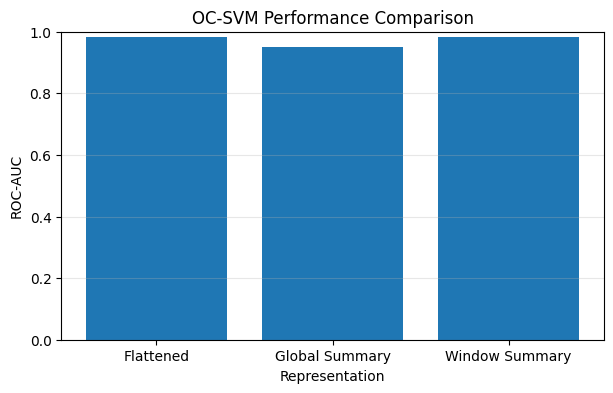

In [216]:

def global_summary(X):
    features = np.column_stack([
        np.mean(X, axis=1),
        np.std(X, axis=1),
        np.min(X, axis=1),
        np.max(X, axis=1),
        np.median(X, axis=1)
    ])

    return features



def window_summary(X, n_windows=4):

    window_leng = X.shape[1] // n_windows
    X_window = X.reshape(X.shape[0],n_windows,window_leng)


    mean_features = np.mean(X_window,axis=2)
    std_features = np.std(X_window,axis=2)


    features = np.concatenate([mean_features,std_features],axis=1)
    return features



# Create representations

representations = {

    "Flattened": (
        X_train_normal,
        X_test_raw
    ),

    "Global Summary": (
        global_summary(X_train_normal),
        global_summary(X_test_raw)
    ),

    "Window Summary": (
        window_summary(X_train_normal),
        window_summary(X_test_raw)
    )
}



results = []


for name, (xtrain, xtest) in representations.items():

    scaler_rep = StandardScaler()

    xtrain_scaled = scaler_rep.fit_transform(xtrain)
    Xtest_scaled = scaler_rep.transform(xtest)


    model = OneClassSVM(kernel="rbf",nu=0.1,gamma="scale")


    model.fit(xtrain_scaled)
    score = -model.decision_function(Xtest_scaled)
    auc = roc_auc_score(y_test,score)


    results.append( [name, xtrain.shape[1] ,auc] )



results = pd.DataFrame(
    results,
    columns=[
        "Representation",
        "Feature Dimension",
        "ROC-AUC"
    ]
)
print(results)



plt.figure(figsize=(7,4))

plt.bar(results["Representation"],results["ROC-AUC"])
plt.ylabel("ROC-AUC")
plt.xlabel("Representation")
plt.title("OC-SVM Performance Comparison")
plt.ylim(0,1)
plt.grid(axis="y",alpha=0.3)

plt.show()

**Q3**

     nu   ROC-AUC  Number of Support Vectors
0  0.01  0.984247                         54
1  0.05  0.984254                         54
2  0.10  0.984025                         54
3  0.20  0.980069                         68


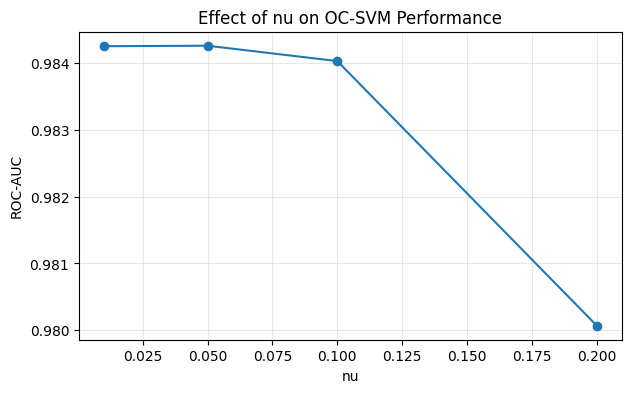

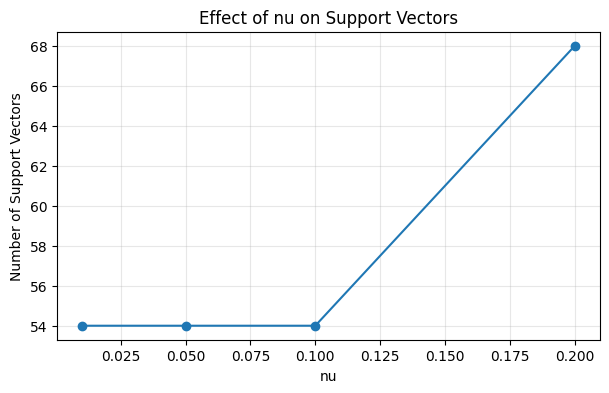

In [217]:

nu_values = [0.01,0.05,0.1,0.2]

nu_results = []


for nu in nu_values:

    model = OneClassSVM(kernel="rbf",gamma="scale",nu=nu)
    model.fit(X_train_scaled)
    anomaly_score = -model.decision_function(X_test_scaled)
    auc = roc_auc_score(y_test,anomaly_score)


    support_vectors = len(model.support_)


    nu_results.append(
        [
            nu,
            auc,
            support_vectors
        ]
    )



nu_results = pd.DataFrame(
    nu_results,
    columns=[
        "nu",
        "ROC-AUC",
        "Number of Support Vectors"
    ]
)


print(nu_results)



plt.figure(figsize=(7,4))

plt.plot(nu_results["nu"], nu_results["ROC-AUC"],marker="o")
plt.xlabel("nu")
plt.ylabel("ROC-AUC")
plt.title("Effect of nu on OC-SVM Performance")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(7,4))

plt.plot(nu_results["nu"],nu_results["Number of Support Vectors"],marker="o")
plt.xlabel("nu")
plt.ylabel("Number of Support Vectors")
plt.title("Effect of nu on Support Vectors")
plt.grid(alpha=0.3)

plt.show()

**Q4**

In [196]:

def markov_log_probability(z, pi, A):
    log_prob = np.log(pi[z[0] - 1])

    for t in range(1, len(z)):
        current_state = z[t] - 1
        previous_state = z[t-1] - 1

        log_prob += np.log(A[previous_state, current_state])

    return log_prob



pi = np.array([0.8,0.2])

A = np.array([[0.95, 0.05],[0.10, 0.90]])

z = np.array([1, 1, 2, 2, 1])


log_probability = markov_log_probability(z,pi,A)

print("State sequence:", z)
print("Log probability:", log_probability)
print("Probability:", np.exp(log_probability))


State sequence: [1 1 2 2 1]
Log probability: -5.678114727907623
Probability: 0.003420000000000001


**Q5**

Hidden states:
[1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

Observations:
[ 2.39541839  2.10289853  2.22411868  2.27479867  2.20870601  2.03781972
  2.33032232  2.77634915  2.80559159  2.12800845  2.3625308   2.78337419
 -1.21043628 -0.56028101 -0.53996903  0.51159967 -0.11839342 -0.92630061
 -0.84660481 -1.38774894 -1.63872005 -0.61892138 -0.68829407 -1.05432474
 -1.4206537  -1.19802079  0.28601959 -1.48347154 -1.85851515 -0.59016237
 -1.22487028 -0.46030002 -0.54228186 -1.76301408 -0.60964443 -1.15689548
 -0.33178259 -0.33204396 -1.59927813 -1.81122186 -0.3624235  -0.44654335
 -1.56609171 -0.35359787 -1.00800788 -2.19897201 -1.27394803 -1.22275575
 -2.4188369  -0.21902462]


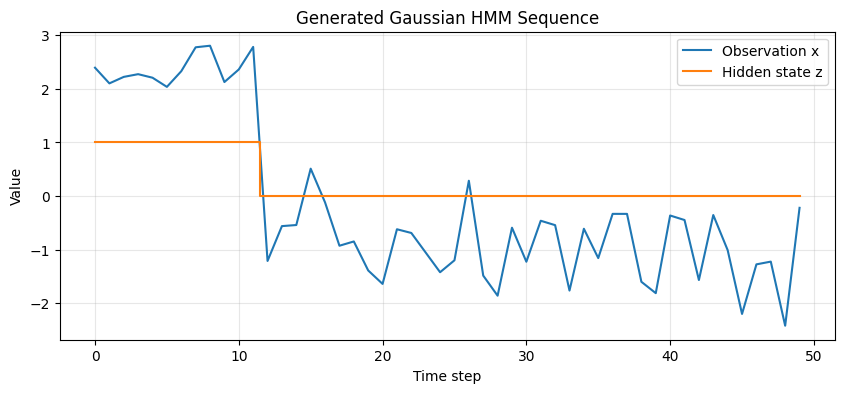

In [197]:


def generate_hmm_sequence(pi, A, means, variances, T):
    ## K=2 is for question
    K = len(pi)

    z = np.zeros(T, dtype=int)
    x = np.zeros(T)

    z[0] = np.random.choice(K,p=pi)
    x[0] = np.random.normal(means[z[0]],np.sqrt(variances[z[0]]))

    for t in range(1, T):

        z[t] = np.random.choice(K,p=A[z[t-1]])
        x[t] = np.random.normal(means[z[t]],np.sqrt(variances[z[t]]))

    return z, x

pi = np.array([0.8,0.2])

A = np.array([[0.95, 0.05],[0.10, 0.90]])

# state 0 -> N(-1,0.6^2)
# state 1 -> N(2,0.3^2)
means = np.array([-1,2])

variances = np.array([0.6**2,0.3**2])


# Sequence length
T = 50
z, x = generate_hmm_sequence(pi,A,means,variances,T)

print("Hidden states:")
print(z)
print("\nObservations:")
print(x)


# Plot generated sequence
plt.figure(figsize=(10,4))
plt.plot(x,label="Observation x")

plt.step(range(T), z, label="Hidden state z",where="mid")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Generated Gaussian HMM Sequence")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("q4.png", dpi=300, bbox_inches="tight")
plt.show()


**Q6**

T = 50

True states:
[1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

Viterbi states:
[1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

State Recovery Accuracy: 100.0
T = 200
State Recovery Accuracy: 89.0


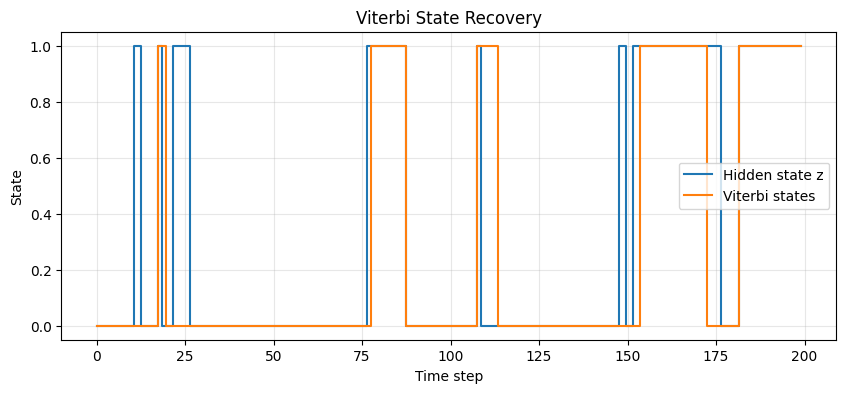

In [198]:

def gaussian_log_prob(x, mean, variance):
    return (-0.5*np.log(2*np.pi*variance) - ((x-mean)**2)/(2*variance))



def viterbi_gaussian_hmm(x, pi, A, means, variances):

    T = len(x)
    K = len(pi)
    ## K=2 in this question
    
    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)


    
    for i in range(K):
        delta[0, i] = (np.log(pi[i]) + gaussian_log_prob(x[0],means[i],variances[i]))


    for t in range(1, T):
        for j in range(K):

            probabilities = (delta[t-1] + np.log(A[:,j]))

            best_previous_state = np.argmax(probabilities)

            delta[t, j] = (probabilities[best_previous_state] + gaussian_log_prob(x[t],means[j],variances[j]))

            psi[t, j] = best_previous_state



    z_hat = np.zeros(T, dtype=int)
    z_hat[-1] = np.argmax(delta[-1])

    for t in range(T-2, -1, -1):
        z_hat[t] = psi[t+1,z_hat[t+1]]

    return z_hat


means = np.array([-0.5, 0.8])
variances = np.array([0.8**2, 0.8**2])
z_pred = viterbi_gaussian_hmm(x,pi,A,means,variances)

accuracy = np.mean(z_pred == z)
accuracy_percent = accuracy*100
print("T = 50\n")
print("True states:")
print(z)

print("\nViterbi states:")
print(z_pred)

print(
    "\nState Recovery Accuracy:",
    accuracy_percent
)

TT=200
z1, x1 = generate_hmm_sequence(pi,A,means,variances,TT)
z1_pred = viterbi_gaussian_hmm(x1,pi,A,means,variances)
accuracy1 = np.mean(z1_pred == z1)
accuracy1_percent = accuracy1*100
print(
    "T = 200\nState Recovery Accuracy:",
    accuracy1_percent
)
# Plot comparison

plt.figure(figsize=(10,4))

plt.step(range(len(z1)), z1, label="Hidden state z",where="mid")
plt.step(range(len(z1_pred)), z1_pred, label="Viterbi states",where="mid")
plt.xlabel("Time step")
plt.ylabel("State")

plt.title("Viterbi State Recovery")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Q7**

In [199]:

def markov_probability(z, pi, A):

    prob = pi[z[0]]

    for t in range(1, len(z)):
        prob *= A[z[t-1], z[t]]

    return prob



T = 5000

z_long = np.zeros(T, dtype=int)
z_long[0] = np.random.choice(2,p=pi)



for t in range(1, T):

    z_long[t] = np.random.choice(2,p=A[z_long[t-1]])

p_direct = markov_probability(z_long,pi,A)

log_p = markov_log_probability(z_long + 1,pi,A)

print("Direct probability:")
print(p_direct)

print("\nLog probability:")
print(log_p)


print("\nProbability from log:")
print(np.exp(log_p))

Direct probability:
0.0

Log probability:
-1166.3527174801877

Probability from log:
0.0


**Q8**

- part a

In [200]:

np.random.seed(40)

T = 100

group_1 = np.random.normal(0,1,50)
group_2 = np.random.normal(4,1,50)


x1 = np.concatenate([group_1,group_2])
x2 = np.concatenate([group_1,group_2])

np.random.shuffle(x2)


- part b

,Statistic,x1,x2
0,Mean,1.977210,1.977210
1,Variance,4.540181,4.540181
2,Minimum,-1.844401,-1.844401
3,Maximum,6.212747,6.212747


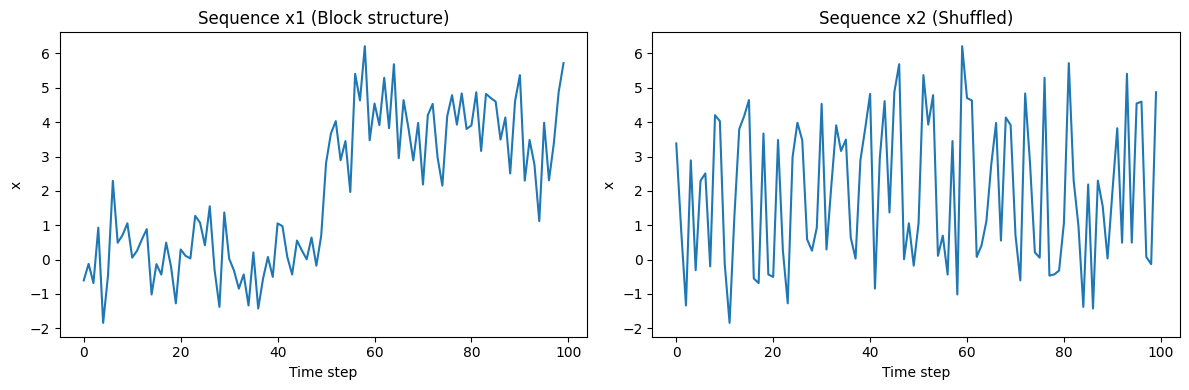

In [201]:

stats_table = pd.DataFrame(
    {
        "Statistic": [
            "Mean",
            "Variance",
            "Minimum",
            "Maximum"
        ],
        "x1": [
            np.mean(x1),
            np.var(x1),
            np.min(x1),
            np.max(x1)
        ],
        "x2": [
            np.mean(x2),
            np.var(x2),
            np.min(x2),
            np.max(x2)
        ]
    }
)


display(stats_table)


plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
plt.plot(x1)
plt.title("Sequence x1 (Block structure)")
plt.xlabel("Time step")
plt.ylabel("x")

plt.subplot(1,2,2)
plt.plot(x2)
plt.title("Sequence x2 (Shuffled)")
plt.xlabel("Time step")
plt.ylabel("x")


plt.tight_layout()
plt.show()



- part c

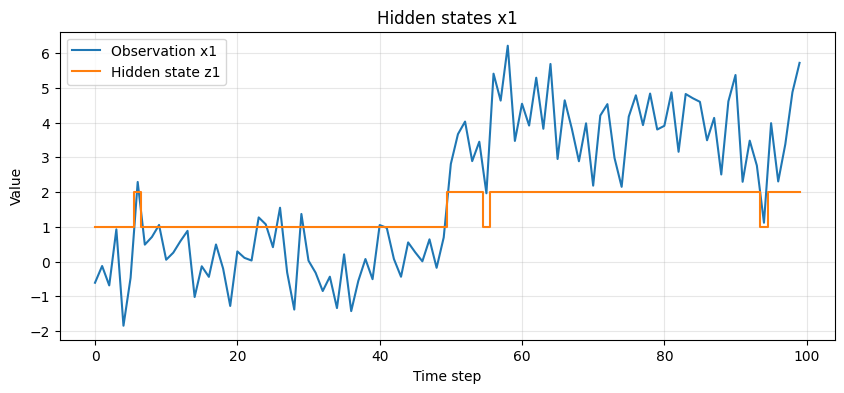

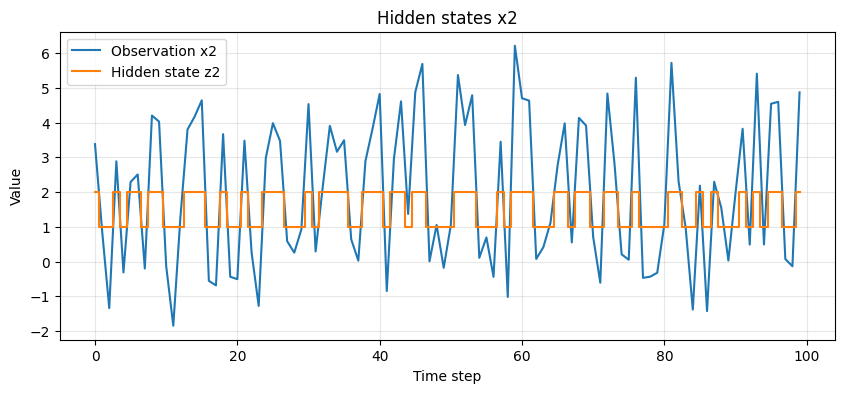


Joint feature vector Psi(x1,z1):
[  4.72663534 192.99438322  47.           4.           3.
  45.        ]

Joint feature vector Psi(x2,z2):
[  4.72663534 192.99438322  25.          26.          26.
  22.        ]


In [202]:

def assign_states(x):
    # z=1 if x<2, else z=2
    z = np.where(x < 2,1,2)
    return z



def joint_feature_vector(x, z, K=2):

    features = []
    transitions = np.zeros((K,K))


    for k in range(1, K+1):
        features.append(np.sum(x[z == k]))

    for t in range(len(z)-1):
        i = z[t]-1
        j = z[t+1]-1
        transitions[i,j] += 1
    features.extend(transitions.flatten())

    return np.array(features)



z1 = assign_states(x1)
z2 = assign_states(x2)

psi1 = joint_feature_vector(x1,z1)
psi2 = joint_feature_vector(x2,z2)



plt.figure(figsize=(10,4))
plt.plot(x1,label="Observation x1")
plt.step(range(T), z1, label="Hidden state z1",where="mid")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Hidden states x1")
plt.legend()
plt.grid(alpha=0.3)

plt.figure(figsize=(10,4))
plt.plot(x2,label="Observation x2")
plt.step(range(T), z2, label="Hidden state z2",where="mid")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Hidden states x2")
plt.legend()
plt.grid(alpha=0.3)

plt.show()




print("\nJoint feature vector Psi(x1,z1):")

print(psi1)


print("\nJoint feature vector Psi(x2,z2):")

print(psi2)


- part d

In [203]:


difference = np.abs(psi1 - psi2)



psi_table = pd.DataFrame(
    {
        "Feature": [
            "Emission - State 1",
            "Emission - State 2",
            "Transition 1→1",
            "Transition 1→2",
            "Transition 2→1",
            "Transition 2→2"
        ],

        "Psi(x1,z1)": psi1,

        "Psi(x2,z2)": psi2,

        "Absolute Difference": difference
    }
)

display(psi_table.round(3))


,Feature,"Psi(x1,z1)","Psi(x2,z2)",Absolute Difference
0,Emission - State 1,4.727,4.727,0.0
1,Emission - State 2,192.994,192.994,0.0
2,Transition 1→1,47.000,25.000,22.0
3,Transition 1→2,4.000,26.000,22.0
4,Transition 2→1,3.000,26.000,23.0
5,Transition 2→2,45.000,22.000,23.0


**Q9**

- part a

In [204]:

def compute_joint_features(x, z, K):
    T = len(x)
    features = []
    transitions = np.zeros((K,K))


  
    for t in range(T-1):
        i = z[t]-1
        j = z[t+1]-1
        transitions[i,j] += 1

    transitions = transitions / (T-1)
    features.extend(transitions.flatten())

    for k in range(1, K+1):
        if np.sum(z==k) > 0:
            mean = np.mean(x[z==k])
        else:
            mean = 0
        features.append(mean)


    return np.array(features)





- part b

In [205]:

np.random.seed(42)
T = 100
K = 2

sequences = []
labels = []

for i in range(200):
    x = np.random.normal(0,1,T)

    sequences.append(x)
    labels.append(0)

for i in range(50):
    x = np.random.normal(0,1,T)
    start = np.random.randint(0,T-20)
    x[start:start+20] = np.random.normal(4,1,20)

    sequences.append(x)
    labels.append(1)



sequences = np.array(sequences)
labels = np.array(labels)



- part c

Psi shape: (250, 6)


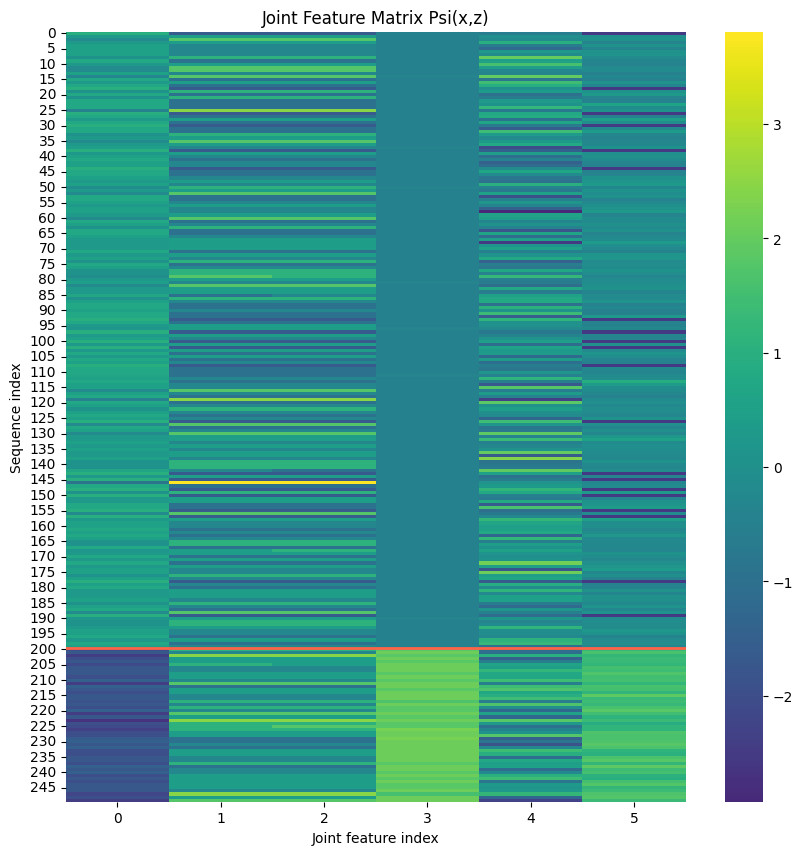

In [206]:

Psi = []


for x in sequences:

    z = assign_states(x)
    psi = compute_joint_features(x,z,K)
    Psi.append(psi)

Psi = np.array(Psi)
Psi_scaled = StandardScaler().fit_transform(Psi)


print("Psi shape:", Psi.shape)


plt.figure(figsize=(10,10))

sns.heatmap(Psi_scaled,cmap="viridis", center =0)

plt.axhline(200,color="tomato",linewidth=2)
plt.xlabel("Joint feature index")
plt.ylabel("Sequence index")
plt.title("Joint Feature Matrix Psi(x,z)")

plt.show()




**Q10**

In [207]:
X_hmad_train = X_train_normal.copy()
K = 2
NU_HMAD = 0.1
EPS = 1e-8
M = 10

- part a

In [208]:

pooled_observations = X_hmad_train.reshape(-1, 1)


kmeans_hmad = KMeans(n_clusters=K,n_init=10,random_state=42)
kmeans_hmad.fit(pooled_observations)


means_hmad = kmeans_hmad.cluster_centers_.flatten()
ini = kmeans_hmad.labels_

variances_hmad = np.array([
    np.var(pooled_observations[ini == k]) for k in range(K)
])

variances_hmad = np.maximum(variances_hmad, EPS)


pi_hmad = np.full(K, 1 / K)

A_hmad = np.array([
    [0.9,0.1],
    [0.1,0.9]
])

print("Initial emission means:")
print(np.round(means_hmad, 4))

print("\nInitial emission variances:")
print(np.round(variances_hmad, 4))

print("\nInitial state probabilities:")
print(np.round(pi_hmad, 4))

print("\nInitial transition matrix:")
print(np.round(A_hmad, 4))

Initial emission means:
[ 0.1753 -2.8316]

Initial emission variances:
[0.4577 1.1243]

Initial state probabilities:
[0.5 0.5]

Initial transition matrix:
[[0.9 0.1]
 [0.1 0.9]]


- part b

In [209]:
def update_hmm_parameters(X,state_paths,old_means,old_variances,K,eps=1e-8):
    
    # Update initial state probabilities
    ini = np.full(K, eps)
    for z in state_paths:
        ini[z[0]] += 1

    new_pi = ini / np.sum(ini)

    # Update transition matrix
    trans_count = np.full((K, K), eps)
    for z in state_paths:
        for t in range(1, len(z)):
            pre = z[t - 1]
            curr = z[t]
            trans_count[pre,curr] += 1

    new_A = trans_count / trans_count.sum(axis=1,keepdims=True)


    # Update Gaussian emission parameters
    new_means = old_means.copy()
    new_variances = old_variances.copy()

    for k in range(K):
        state_values = [x[z == k] for x,z in zip(X,state_paths) if np.any(z == k)]
        if len(state_values) > 0:
            state_values = np.concatenate(state_values)

            new_means[k] = np.mean(state_values)
            new_variances[k] = max(np.var(state_values),eps)

    return new_pi, new_A, new_means, new_variances



##Loop

change_history = []
mean_score_history = []
previous_state_paths = None

for i in range(1, M + 1):

    hmad_train_paths = np.array([
        viterbi_gaussian_hmm(x,pi_hmad,A_hmad,means_hmad,variances_hmad) for x in X_hmad_train
    ])
    hmad_train_features = np.array([
        compute_joint_features(x,z+1,K) for x,z in zip(X_hmad_train,hmad_train_paths)
    ])


    ( pi_hmad,A_hmad,means_hmad,variances_hmad ) = update_hmm_parameters(X_hmad_train,hmad_train_paths,means_hmad,variances_hmad,K,EPS )


    hmad_scaler = StandardScaler()
    hmad_train_features_scaled = (hmad_scaler.fit_transform(hmad_train_features))


   
    hmad_model = OneClassSVM(kernel="rbf",gamma="scale",nu=NU_HMAD)

    hmad_model.fit(hmad_train_features_scaled)

    train_scores = hmad_model.decision_function(hmad_train_features_scaled)
    mean_train_score = np.mean(train_scores)


   
    if previous_state_paths is None:
        changed_fraction = np.nan
    else:
        changed_fraction = np.mean(hmad_train_paths!= previous_state_paths)


    change_history.append(changed_fraction)
    mean_score_history.append(mean_train_score)


    if np.isnan(changed_fraction):
        changed_text = "Not available"
    else:
        changed_text = f"{changed_fraction:.6f}"
    print(
        f"iteration {i}: "
        f"changed fraction = {changed_text}, "
        f"mean decision score = {mean_train_score:.6f}"
    )




    previous_state_paths = hmad_train_paths.copy()

iteration 1: changed fraction = Not available, mean decision score = 0.657256
iteration 2: changed fraction = 0.006849, mean decision score = 0.350100
iteration 3: changed fraction = 0.006042, mean decision score = 0.498019
iteration 4: changed fraction = 0.005651, mean decision score = 0.460353
iteration 5: changed fraction = 0.003205, mean decision score = 0.368455
iteration 6: changed fraction = 0.002006, mean decision score = 0.360932
iteration 7: changed fraction = 0.000636, mean decision score = 0.362906
iteration 8: changed fraction = 0.000807, mean decision score = 0.365079
iteration 9: changed fraction = 0.000122, mean decision score = 0.367541
iteration 10: changed fraction = 0.000049, mean decision score = 0.368330


- part c

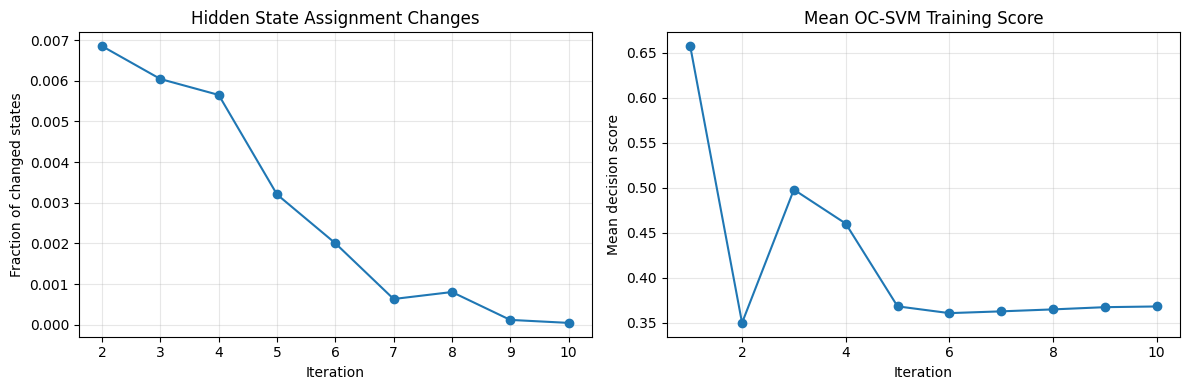

In [210]:
iterations = np.arange(1,len(change_history)+1)


fig, axes = plt.subplots(1,2,figsize=(12, 4))


# Fraction of changed hidden states
axes[0].plot(iterations,change_history,marker="o")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Fraction of changed states")
axes[0].set_title("Hidden State Assignment Changes")
axes[0].grid(alpha=0.3)


# Mean OC-SVM decision score
axes[1].plot(iterations,mean_score_history,marker="o")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean decision score")
axes[1].set_title("Mean OC-SVM Training Score")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()


- part d

In [211]:
print("Learned emission means at convergence:")
print(np.round(means_hmad, 4))


print("\nLearned transition matrix at convergence:")
print(np.round(A_hmad, 4))

Learned emission means at convergence:
[ 0.2076 -2.0925]

Learned transition matrix at convergence:
[[0.9981 0.0019]
 [0.0892 0.9108]]


**Q11**

- part a

In [219]:
hmad_test_paths = []
hmad_test_features = []

for x in X_test_raw:

    z_star = viterbi_gaussian_hmm(x,pi_hmad,A_hmad,means_hmad,variances_hmad)
    psi = compute_joint_features(x,z_star+1,K)
    hmad_test_paths.append(z_star)
    hmad_test_features.append(psi)

hmad_test_paths = np.array(hmad_test_paths)
hmad_test_features = np.array(hmad_test_features)
hmad_test_features_scaled = hmad_scaler.transform(hmad_test_features)


hmad_scores = hmad_model.decision_function(hmad_test_features_scaled)


print("Number of test sequences:", len(hmad_scores))
print("HMAD test feature shape:", hmad_test_features.shape)

Number of test sequences: 4500
HMAD test feature shape: (4500, 6)


- part b

In [220]:

hmad_anomaly_scores = -hmad_scores
hmad_auc = roc_auc_score(y_test,hmad_anomaly_scores)


baseline_scaler = StandardScaler()

X_baseline_train_scaled = baseline_scaler.fit_transform(X_train_normal)
X_baseline_test_scaled = baseline_scaler.transform(X_test_raw)


baseline_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.1
)
baseline_model.fit(X_baseline_train_scaled)


baseline_scores = baseline_model.decision_function(X_baseline_test_scaled)
baseline_auc = roc_auc_score(y_test,-baseline_scores)
auc_comparison = pd.DataFrame({
    "Model": [
        "OC-SVM Baseline",
        "HMAD"
    ],
    "ROC-AUC": [
        baseline_auc,
        hmad_auc
    ]
})
display(auc_comparison)

,Model,ROC-AUC
0,OC-SVM Baseline,0.984025
1,HMAD,0.933161


- part c

In [221]:
t_test_features = []
for x in X_test_raw:
    z_triv = np.ones(len(x),dtype=int)
    psi_triv = compute_joint_features(x,z_triv,K)
    t_test_features.append(psi_triv)

t_test_features = np.array(t_test_features)


t_test_features_scaled = hmad_scaler.transform(t_test_features)


t_scores = hmad_model.decision_function(t_test_features_scaled)
trivi_auc = roc_auc_score(y_test,-t_scores)


print(f"HMAD with Viterbi ROC-AUC: {hmad_auc:.6f}")
print(f"HMAD without Viterbi ROC-AUC: {trivi_auc:.6f}")
print(f"AUC difference: {hmad_auc - trivi_auc:.6f}")

HMAD with Viterbi ROC-AUC: 0.933161
HMAD without Viterbi ROC-AUC: 0.496717
AUC difference: 0.436443


- part d

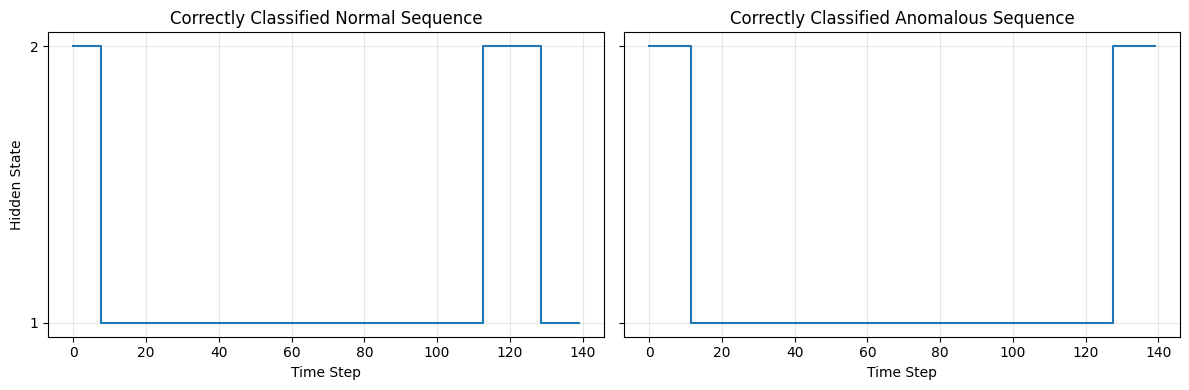

In [232]:
# score >= 0  -> normal
# score < 0   -> anomaly
hmad_pred = (hmad_scores < 0).astype(int)


normal_indices = np.where((y_test == 0) & (hmad_pred == 0))[0]

anomaly_indices = np.where((y_test == 1) & (hmad_pred == 1))[0]

normal_index = normal_indices[0]
anomaly_index = anomaly_indices[0]

normal_path = hmad_test_paths[normal_index] + 1
anomaly_path = hmad_test_paths[anomaly_index] + 1


# Plot the two paths side by side
fig, axes = plt.subplots(1,2,figsize=(12, 4),sharey=True)


axes[0].step(range(len(normal_path)),normal_path,where="mid")
axes[0].set_title("Correctly Classified Normal Sequence")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Hidden State")
axes[0].set_yticks([1, 2])
axes[0].grid(alpha=0.3)


axes[1].step(range(len(anomaly_path)),anomaly_path,where="mid")
axes[1].set_title("Correctly Classified Anomalous Sequence")
axes[1].set_xlabel("Time Step")
axes[1].set_yticks([1, 2])
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()